In [9]:
import datasets

In [10]:
publay = datasets.load_dataset("jordanparker6/publaynet", split="train")

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# PubLayNet category mapping (category_id -> label)
CATEGORY_NAMES = {0: "text", 1: "title", 2: "list", 3: "table", 4: "figure"}

def show_bboxes(sample, ax=None):
    """Display image with bounding boxes and labels."""
    img = sample["image"]
    annotations = sample["annotations"]
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(12, 14))
    
    ax.imshow(img)
    
    for ann in annotations:
        bbox = ann["bbox"]  # [x, y, width, height]
        x, y, w, h = bbox
        cat_id = ann.get("category_id", ann.get("category", {}).get("category_id", 0))
        label = ann.get("category", {}).get("name", CATEGORY_NAMES.get(cat_id, str(cat_id)))
        
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="lime", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, y - 2, label, fontsize=8, color="lime", va="bottom", 
                bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7))
    
    ax.axis("off")
    return ax

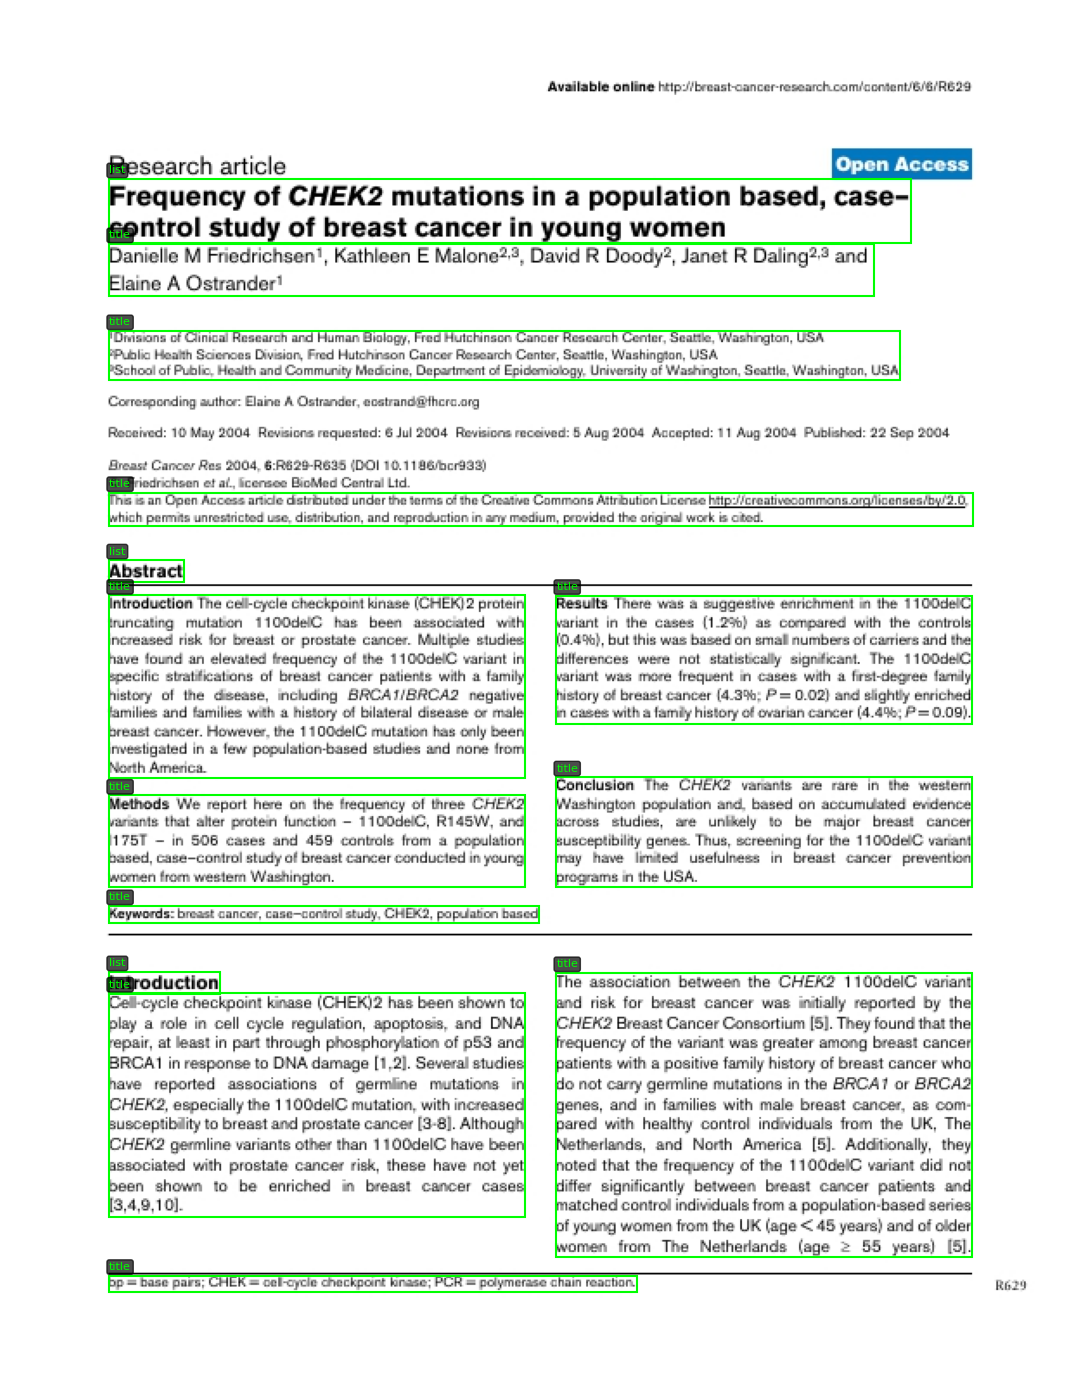

In [12]:
# Visualize a sample
sample = publay[0]
show_bboxes(sample)
plt.tight_layout()
plt.show()

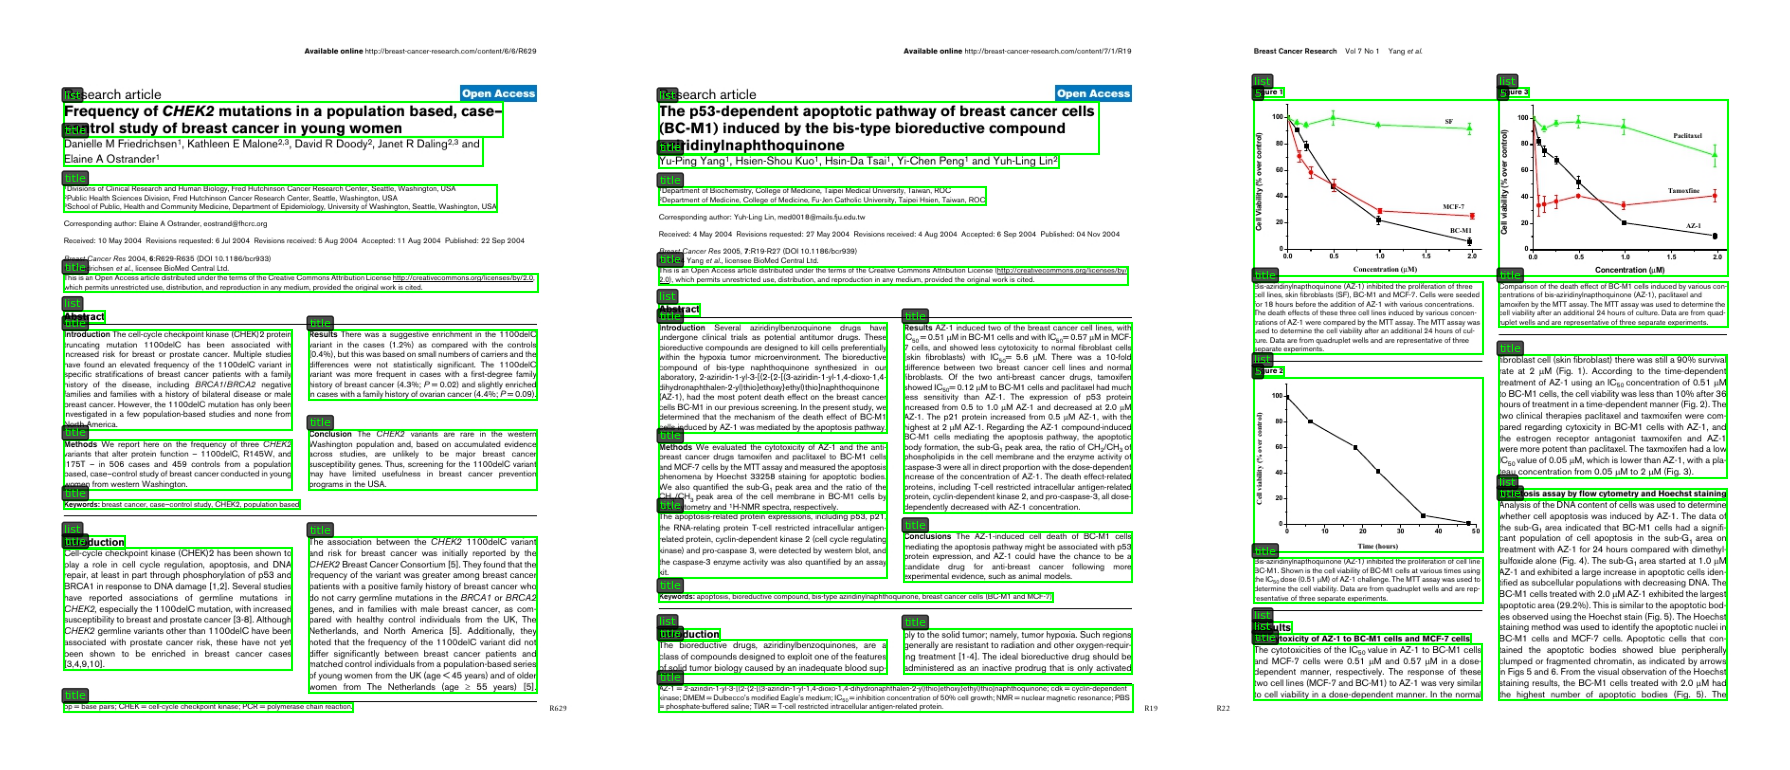

In [13]:
# Visualize multiple samples (optional)
n_samples = 3
fig, axes = plt.subplots(1, n_samples, figsize=(6 * n_samples, 8))
for i, ax in enumerate(axes):
    show_bboxes(publay[i], ax=ax)
plt.tight_layout()
plt.show()

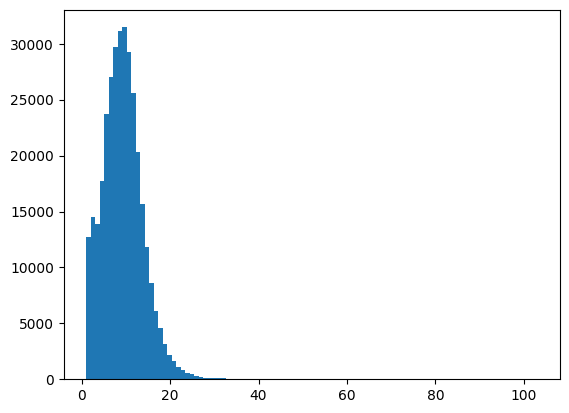

In [ ]:
lens = []
for i in range(len(publay)):
    lens.append(len(publay[i]["annotations"]))

103


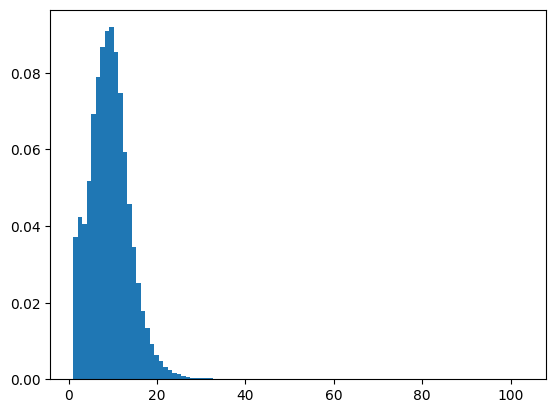

In [17]:
print(max(lens))
plt.hist(lens, bins=100, density=True)
plt.show()